In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time

In [ ]:
n_train_points = 5000      # количество точек PDE
n_train_points_bc = 3000   # количество граничных точек
n_train_points_ic = 1500   # количество начальных точек
w_pde, w_bc, w_ic = 10, 5, 5   # веса компонент функции потерь
num_epochs = 10000         # количество эпох обучения
t_max = 2                   # максимальное время (безразмерное)
seed = 42                   # для воспроизводимости
np.random.seed(seed)
torch.manual_seed(seed)

L_star = 2 * np.pi
T_star = t_max
U_star = 1.0
Fo = T_star / (L_star ** 2)  # число Фурье
b = 0.05                     # радиус пятна
sources = [
    (0.3, 0.7, 10.0),        # (x_s, y_s, A)
    (0.7, 0.3, 10.0)
]

In [5]:
def source_term(x, y):
    q = torch.zeros_like(x)
    for x_s, y_s, A in sources:
        q += A * torch.exp(-((x - x_s)**2 + (y - y_s)**2) / (2 * b**2))
    return q


In [ ]:
class HeatNet2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(3, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 1)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        return self.layers(inputs)


In [ ]:
def generate_training_points():
    # Точки внутри области (для PDE)
    sobol_3d = qmc.Sobol(d=3, scramble=True)
    n_sobol = 2 ** int(np.ceil(np.log2(n_train_points)))
    sobol_points = sobol_3d.random(n_sobol)[:n_train_points]

    x_random = torch.FloatTensor(sobol_points[:, 0:1])
    y_random = torch.FloatTensor(sobol_points[:, 1:2])
    t_random = torch.FloatTensor(sobol_points[:, 2:3])

    # Значение источника в этих точках
    q_random = source_term(x_random, y_random)

    # Граничные точки (4 грани)
    n_per_boundary = n_train_points_bc // 4
    sobol_2d = qmc.Sobol(d=2, scramble=True)
    n_sobol_2d = 2 ** int(np.ceil(np.log2(n_per_boundary)))
    surface_points = sobol_2d.random(n_sobol_2d)[:n_per_boundary]

    # Грань 1: x = 0, u = 1
    x_left = torch.zeros(n_per_boundary, 1)
    y_left = torch.FloatTensor(surface_points[:, 0:1])
    t_left = torch.FloatTensor(surface_points[:, 1:2])
    u_left = torch.ones(n_per_boundary, 1)

    # Грань 2: x = 1, u = -1
    x_right = torch.ones(n_per_boundary, 1)
    y_right = torch.FloatTensor(surface_points[:, 0:1])
    t_right = torch.FloatTensor(surface_points[:, 1:2])
    u_right = -torch.ones(n_per_boundary, 1)

    # Грань 3: y = 0, u = -1
    x_bottom = torch.FloatTensor(surface_points[:, 0:1])
    y_bottom = torch.zeros(n_per_boundary, 1)
    t_bottom = torch.FloatTensor(surface_points[:, 1:2])
    u_bottom = -torch.ones(n_per_boundary, 1)

    # Грань 4: y = 1, u = 1
    x_top = torch.FloatTensor(surface_points[:, 0:1])
    y_top = torch.ones(n_per_boundary, 1)
    t_top = torch.FloatTensor(surface_points[:, 1:2])
    u_top = torch.ones(n_per_boundary, 1)

    x_boundary = torch.cat([x_left, x_right, x_bottom, x_top], dim=0)
    y_boundary = torch.cat([y_left, y_right, y_bottom, y_top], dim=0)
    t_boundary = torch.cat([t_left, t_right, t_bottom, t_top], dim=0)
    u_boundary = torch.cat([u_left, u_right, u_bottom, u_top], dim=0)

    # Начальные точки (t=0)
    sobol_2d_ic = qmc.Sobol(d=2, scramble=True)
    n_sobol_ic = 2 ** int(np.ceil(np.log2(n_train_points_ic)))
    ic_points = sobol_2d_ic.random(n_sobol_ic)[:n_train_points_ic]

    x_initial = torch.FloatTensor(ic_points[:, 0:1])
    y_initial = torch.FloatTensor(ic_points[:, 1:2])
    t_initial = torch.zeros(n_train_points_ic, 1)
    u_initial = torch.zeros(n_train_points_ic, 1)

    return {
        'pde': (x_random, y_random, t_random, q_random),
        'boundary': (x_boundary, y_boundary, t_boundary, u_boundary),
        'initial': (x_initial, y_initial, t_initial, u_initial)
    }


In [ ]:
def compute_derivatives(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    
    u = model(x, y, t)
    
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    
    return u_t, u_xx, u_yy

In [ ]:
def compute_loss(model, data, batch_size=512):
    total_pde, total_bc, total_ic = [], [], []

    # PDE loss (невязка уравнения)
    x_random, y_random, t_random, q_random = data['pde']
    for i in range(0, len(x_random), batch_size):
        x_batch = x_random[i:i+batch_size]
        y_batch = y_random[i:i+batch_size]
        t_batch = t_random[i:i+batch_size]
        q_batch = q_random[i:i+batch_size]
        
        u_t, u_xx, u_yy = compute_derivatives(model, x_batch, y_batch, t_batch)
        residual = u_t - Fo * (u_xx + u_yy) - q_batch
        total_pde.append(torch.mean(residual ** 2))
    # BC loss (граничные условия)
    x_boundary, y_boundary, t_boundary, u_boundary_true = data['boundary']
    for i in range(0, len(x_boundary), batch_size):
        x_batch = x_boundary[i:i+batch_size]
        y_batch = y_boundary[i:i+batch_size]
        t_batch = t_boundary[i:i+batch_size]
        u_true_batch = u_boundary_true[i:i+batch_size]
        u_pred_batch = model(x_batch, y_batch, t_batch)
        total_bc.append(torch.mean((u_pred_batch - u_true_batch) ** 2))

    # IC loss (начальное условие)
    x_initial, y_initial, t_initial, u_initial_true = data['initial']
    for i in range(0, len(x_initial), batch_size):
        x_batch = x_initial[i:i+batch_size]
        y_batch = y_initial[i:i+batch_size]
        t_batch = t_initial[i:i+batch_size]
        u_true_batch = u_initial_true[i:i+batch_size]
        u_pred_batch = model(x_batch, y_batch, t_batch)
        total_ic.append(torch.mean((u_pred_batch - u_true_batch) ** 2))

    pde_error = torch.mean(torch.stack(total_pde))
    bc_error = torch.mean(torch.stack(total_bc))
    ic_error = torch.mean(torch.stack(total_ic))
    total_loss = w_pde * pde_error + w_bc * bc_error + w_ic * ic_error
    return total_loss, pde_error, bc_error, ic_error

In [ ]:
def train_model():
    model = HeatNet2D()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=200,
        threshold=1e-3, min_lr=1e-6, verbose=True
    )

    data = generate_training_points()
    losses = {'pde': [], 'bc': [], 'ic': [], 'total': [], 'lr': []}

    print("2D PINN для уравнения теплопроводности с точечными источниками")
    print(f"Безразмерные масштабы: L*={L_star:.2f}, T*={T_star:.2f}, U*={U_star:.2f}")
    print(f"Число Фурье Fo = {Fo:.6f}")
    print(f"Источники: {sources}")
    print(f"Радиус источника b = {b}")
    print(f"Точки: PDE={n_train_points}, BC={n_train_points_bc}, IC={n_train_points_ic}")
    print(f"Веса: w_pde={w_pde}, w_bc={w_bc}, w_ic={w_ic}")

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        total, pde, bc, ic = compute_loss(model, data)
        total.backward()
        optimizer.step()
        scheduler.step(total.item())

        losses['pde'].append(pde.item())
        losses['bc'].append(bc.item())
        losses['ic'].append(ic.item())
        losses['total'].append(total.item())
        losses['lr'].append(optimizer.param_groups[0]['lr'])

        if epoch % 500 == 0:
            print(f"Эпоха {epoch:5d}: Total={total.item():.6f}, "
                  f"PDE={pde.item():.6f}, BC={bc.item():.6f}, IC={ic.item():.6f}, lr={optimizer.param_groups[0]['lr']}")

    return model, data, losses

In [ ]:
def plot_training(losses):
    plt.figure(figsize=(15, 5))
    epochs = range(len(losses['total']))
    plt.semilogy(epochs, [w_pde * val for val in losses['pde']],
                 'r-', label=f'PDE × {w_pde}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, [w_bc * val for val in losses['bc']],
                 'b-', label=f'BC × {w_bc}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, [w_ic * val for val in losses['ic']],
                 'g-', label=f'IC × {w_ic}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, losses['total'],
                 'k-', label='Total Loss', linewidth=2)
    plt.title(f'Обучение с источниками (Fo={Fo:.4f})')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_solution(model):
    n_points = 100
    x = torch.linspace(0, 1, n_points)
    y = torch.linspace(0, 1, n_points)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    times = [0.1, 0.25, 0.5, 1.0, 2.0]

    # Глобальные min/max для единой цветовой шкалы
    vmin, vmax = float('inf'), float('-inf')
    all_predictions = []

    for t_val in times:
        T_nd = torch.ones_like(X) * (t_val / T_star)
        X_flat = X.reshape(-1, 1)
        Y_flat = Y.reshape(-1, 1)
        T_flat = T_nd.reshape(-1, 1)

        with torch.no_grad():
            u_pred_nd = model(X_flat, Y_flat, T_flat).reshape(n_points, n_points).numpy()
        u_pred = u_pred_nd * U_star
        all_predictions.append(u_pred)

        vmin = min(vmin, u_pred.min())
        vmax = max(vmax, u_pred.max())

    # Отступ для цветовой шкалы
    vmin = vmin - 0.05 * (vmax - vmin)
    vmax = vmax + 0.05 * (vmax - vmin)

    # Второй проход: построение графиков
    fig, axes = plt.subplots(1, 5, figsize=(18, 5))

    for idx, (t_val, u_pred) in enumerate(zip(times, all_predictions)):
        im = axes[idx].contourf(X.numpy(), Y.numpy(), u_pred,
                                levels=50, cmap='RdBu_r',
                                vmin=vmin, vmax=vmax)
        axes[idx].set_title(f't = {t_val:.1f} c')
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].set_aspect('equal')

    plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.1)
    plt.suptitle('Решение с двумя точечными источниками')
    plt.tight_layout()
    plt.show()


In [ ]:
def run_fdm():
    import numpy as np_fdm
    
    # Параметры сетки
    N = 100
    x_fdm = np_fdm.linspace(0, 1, N)
    y_fdm = np_fdm.linspace(0, 1, N)
    h = x_fdm[1] - x_fdm[0]
    
    # Сетка координат для источника
    X_fdm, Y_fdm = np_fdm.meshgrid(x_fdm, y_fdm, indexing='ij')
    
    # Функция источника
    def source_fdm(X, Y):
        Q = np_fdm.zeros_like(X)
        for x_s, y_s, A in sources:
            Q += A * np_fdm.exp(-((X - x_s)**2 + (Y - y_s)**2) / (2 * b**2))
        return Q
    
    Q_nodes = source_fdm(X_fdm, Y_fdm)
    
    # Шаг по времени (условие Куранта)
    dt_max = h**2 / (4 * Fo)
    dt = dt_max * 0.95
    Nt = int(t_max / dt) + 1
    
    print(f"\n--- FDM параметры ---")
    print(f"Сетка: {N}×{N}, h={h:.4f}")
    print(f"dt={dt:.2e}, шагов={Nt}")
    
    # Инициализация
    u_curr = np_fdm.zeros((N, N))
    u_curr[0, :] = 1.0      # x = 0
    u_curr[N-1, :] = -1.0   # x = 1
    u_curr[:, 0] = -1.0     # y = 0
    u_curr[:, N-1] = 1.0    # y = 1
    
    # Моменты для сохранения
    times_save = [0.1, 0.25, 0.5, 1.0, 2.0]
    steps_save = [int(t / dt) for t in times_save]
    solutions = {}
    
    # Основной цикл по времени
    for n in range(Nt):
        u_next = u_curr.copy()
        
        # Явная схема для внутренних узлов
        for i in range(1, N-1):
            for j in range(1, N-1):
                laplacian = (
                    (u_curr[i+1, j] - 2*u_curr[i, j] + u_curr[i-1, j]) +
                    (u_curr[i, j+1] - 2*u_curr[i, j] + u_curr[i, j-1])
                ) / (h * h)
                u_next[i, j] = u_curr[i, j] + Fo * dt * laplacian + dt * Q_nodes[i, j]
        
        # Граничные условия
        u_next[0, :] = 1.0
        u_next[N-1, :] = -1.0
        u_next[:, 0] = -1.0
        u_next[:, N-1] = 1.0
        
        u_curr = u_next
        
        if n in steps_save:
            idx = steps_save.index(n)
            solutions[times_save[idx]] = u_curr.copy()
            print(f"  FDM: зафиксировано в t={times_save[idx]}")
    
    return solutions, X_fdm, Y_fdm


In [ ]:
def compare_pinn_fdm(model, fdm_solutions, X_grid, Y_grid):
    times = [0.1, 0.25, 0.5, 1.0, 2.0]
    errors = []
    
    print("\n" + "="*60)
    print("СРАВНЕНИЕ PINN И FDM (поточечно)")
    print("="*60)
    
    for t in times:
        u_fdm = fdm_solutions[t]
        
        # Решение PINN в тех же узлах
        T_nd = np.ones_like(X_grid) * (t / T_star)
        X_flat = torch.FloatTensor(X_grid.reshape(-1, 1))
        Y_flat = torch.FloatTensor(Y_grid.reshape(-1, 1))
        T_flat = torch.FloatTensor(T_nd.reshape(-1, 1))
        
        with torch.no_grad():
            u_pinn_nd = model(X_flat, Y_flat, T_flat).reshape(X_grid.shape).numpy()
        u_pinn = u_pinn_nd * U_star
    
        # Метрики ошибки
        mae = np.mean(np.abs(u_pinn - u_fdm))
        max_err = np.max(np.abs(u_pinn - u_fdm))
        rmse = np.sqrt(np.mean((u_pinn - u_fdm)**2))
        errors.append((t, mae, max_err, rmse))
        
        print(f"t={t:4.1f}: MAE={mae:.5f}, max error={max_err:.5f}, RMSE={rmse:.5f}")
    
    # Визуализация ошибки для последнего момента
    t_last = times[-1]
    u_fdm_last = fdm_solutions[t_last]
    T_nd_last = np.ones_like(X_grid) * (t_last / T_star)
    X_flat = torch.FloatTensor(X_grid.reshape(-1, 1))
    Y_flat = torch.FloatTensor(Y_grid.reshape(-1, 1))
    T_flat = torch.FloatTensor(T_nd_last.reshape(-1, 1))
    
    with torch.no_grad():
        u_pinn_last = model(X_flat, Y_flat, T_flat).reshape(X_grid.shape).numpy() * U_star
    
    # Абсолютная ошибка
    plt.figure(figsize=(8, 6))
    plt.contourf(X_grid, Y_grid, np.abs(u_pinn_last - u_fdm_last), levels=50, cmap='hot')
    plt.colorbar()
    plt.title(f'Абсолютная ошибка PINN vs FDM, t={t_last} c')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()
    plt.show()
    
    # Сравнение решений
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.contourf(X_grid, Y_grid, u_pinn, levels=50, cmap='RdBu_r')
    plt.colorbar()
    plt.title(f'PINN, t={t_last}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.subplot(1, 2, 2)
    plt.contourf(X_grid, Y_grid, u_fdm, levels=50, cmap='RdBu_r')
    plt.colorbar()
    plt.title(f'FDM, t={t_last}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.suptitle(f'Сравнение PINN и FDM, t={t_last} c')
    plt.tight_layout()
    plt.show()
    
    # График ошибки по времени
    plt.figure(figsize=(8, 5))
    times_list = [e[0] for e in errors]
    mae_list = [e[1] for e in errors]
    plt.semilogy(times_list, mae_list, 'bo-', linewidth=2)
    plt.xlabel('Время t (c)')
    plt.ylabel('MAE')
    plt.title('Средняя абсолютная ошибка PINN vs FDM')
    plt.grid(True)
    plt.show()
    
    return errors


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


2D PINN для уравнения теплопроводности с точечными источниками
Безразмерные масштабы: L*=6.28, T*=2.00, U*=1.00
Число Фурье Fo = 0.050661
Источники: [(0.3, 0.7, 10.0), (0.7, 0.3, 10.0)]
Радиус источника b = 0.05
Точки: PDE=5000, BC=3000, IC=1500
Веса: w_pde=10, w_bc=5, w_ic=5
Эпоха     0: Total=20.261475, PDE=1.492914, BC=1.054607, IC=0.011859, lr=0.0005
Эпоха   500: Total=1.115883, PDE=0.015029, BC=0.122491, IC=0.070627, lr=0.0005


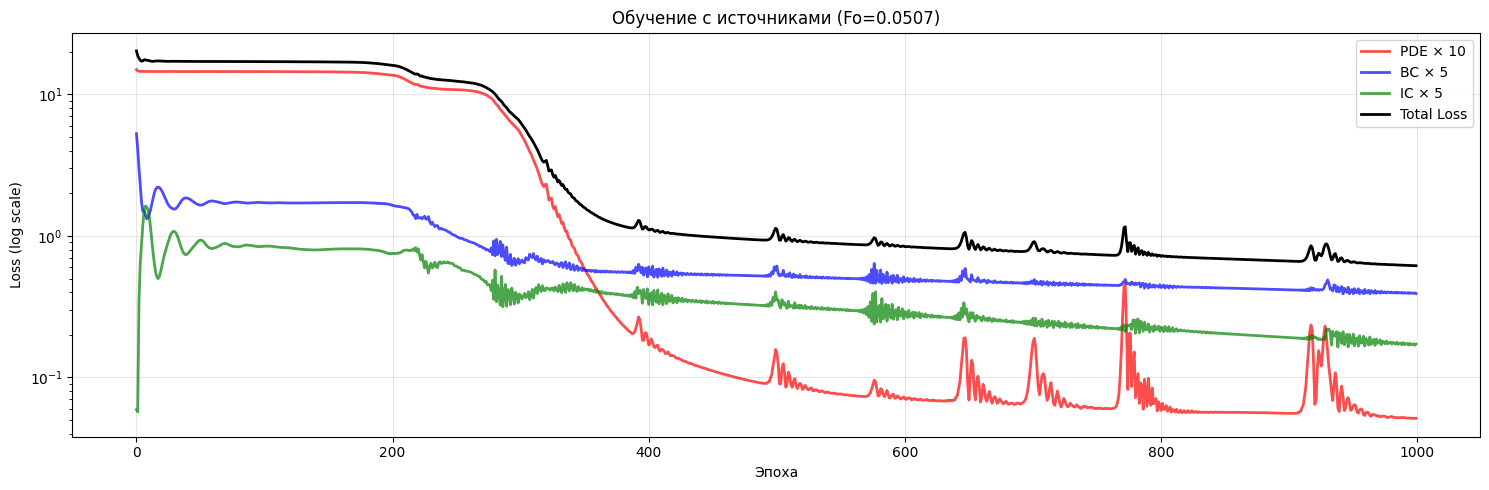

C:\Users\user\AppData\Local\Temp\ipykernel_17616\1442247960.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


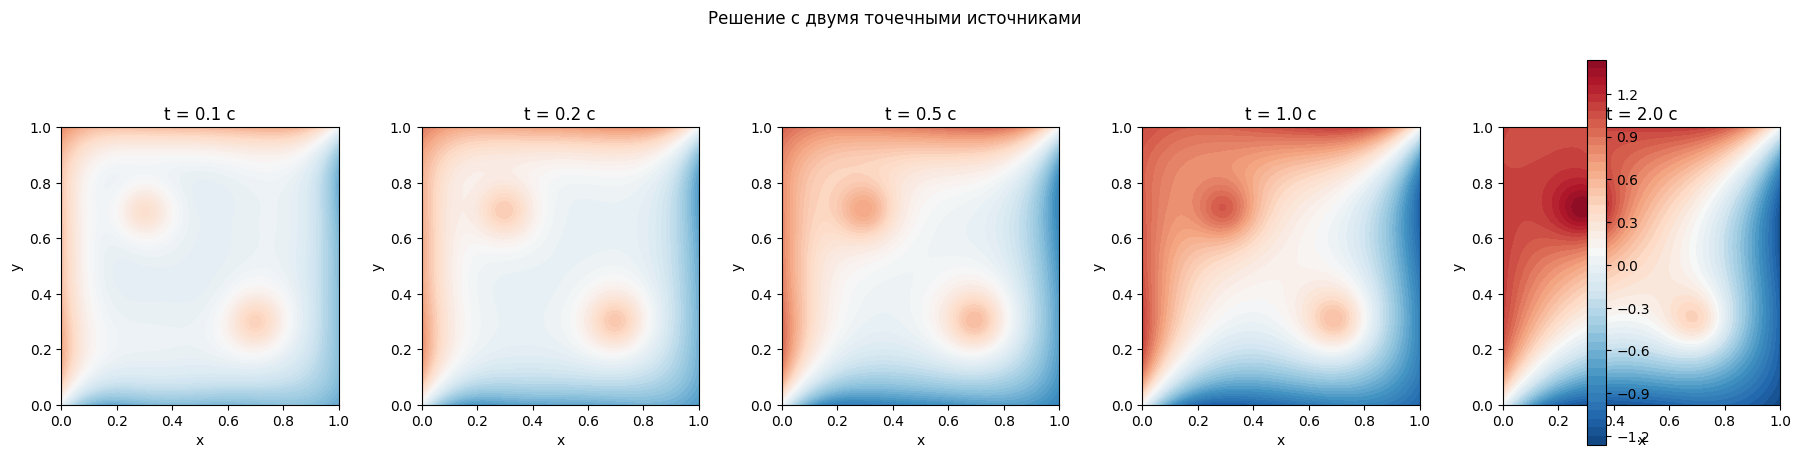

Время выполнения PINN: 936.82 секунд

ЗАПУСК МЕТОДА КОНЕЧНЫХ РАЗНОСТЕЙ

--- FDM параметры ---
Сетка: 100×100, h=0.0101
dt=4.78e-04, шагов=4182
  FDM: сохранено t=0.1
  FDM: сохранено t=0.25
  FDM: сохранено t=0.5
  FDM: сохранено t=1.0
  FDM: сохранено t=2.0
Время выполнения FDM: 73.60 секунд

СРАВНЕНИЕ PINN И FDM (поточечно)
t= 0.1: MAE=0.15898, max error=0.97060, RMSE=0.21281
t= 0.2: MAE=0.20940, max error=0.98022, RMSE=0.24503
t= 0.5: MAE=0.20830, max error=1.01399, RMSE=0.24002
t= 1.0: MAE=0.14552, max error=1.05285, RMSE=0.18870
t= 2.0: MAE=0.09281, max error=1.00334, RMSE=0.11781


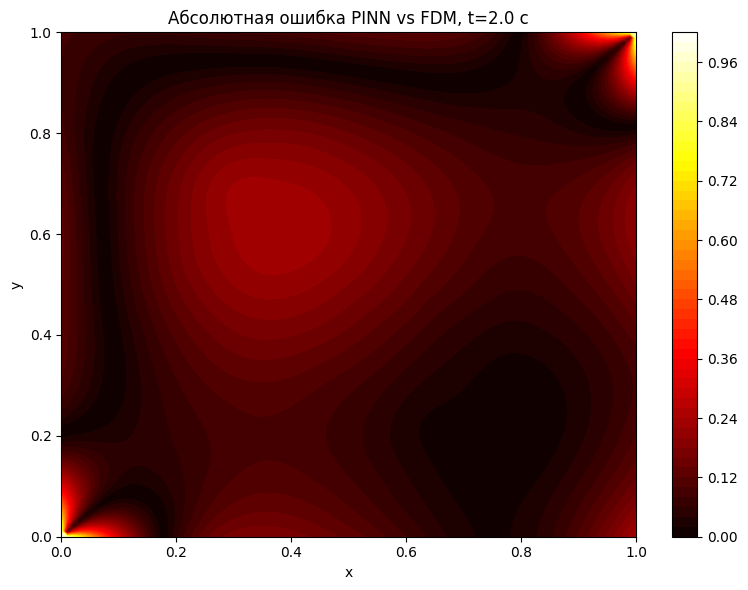

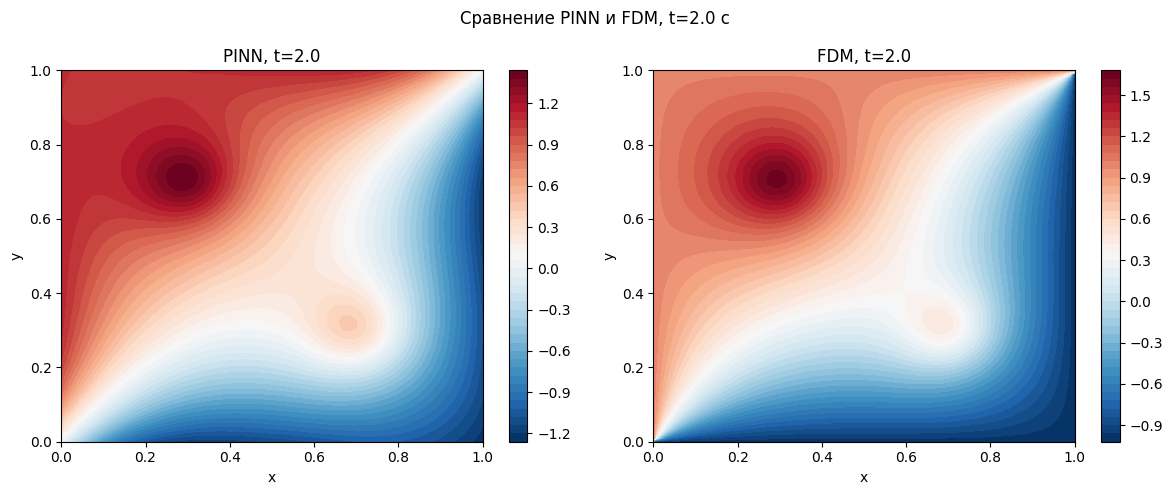

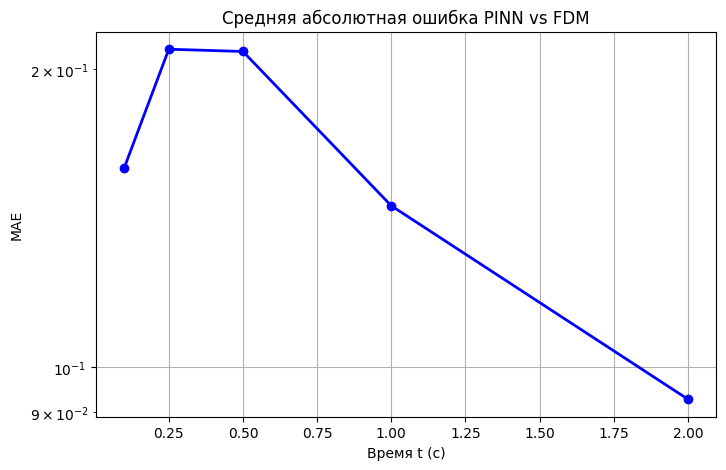


Итог: средняя MAE по всем моментам времени = 0.16300


In [15]:
if __name__ == "__main__":
    start_time = time.time()

    # 1. Обучение PINN
    model, data, losses = train_model()
    plot_training(losses)
    plot_solution(model)

    end_time = time.time()
    print(f"Время выполнения PINN: {end_time - start_time:.2f} секунд")
    
    # 2. Запуск FDM и сравнение
    print("\n" + "="*60)
    print("МЕТОД КОНЕЧНЫХ РАЗНОСТЕЙ")
    print("="*60)
    
    fdm_start = time.time()
    fdm_solutions, X_fdm, Y_fdm = run_fdm()
    fdm_end = time.time()
    print(f"Время выполнения FDM: {fdm_end - fdm_start:.2f} секунд")
    
    # 3. Сравнение
    errors = compare_pinn_fdm(model, fdm_solutions, X_fdm, Y_fdm)
    
    # 4. Вывод итоговой ошибки
    avg_mae = np.mean([e[1] for e in errors])
    print(f"\nИтог: средняя MAE по всем моментам времени = {avg_mae:.5f}")